In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [16]:
#Loading dataset
data_path = "../data/processed_data/clean_news_data.csv"
print("Clean path file:", data_path)

Clean path file: ../data/processed_data/clean_news_data.csv


In [18]:
if not os.path.exists (data_path):
    data_path = None

if data_path is None:
    raise FileNotFoundError(
        "clean_news_data.csv were not found."
    )
df = pd.read_csv(data_path)
print("Shape of clean dataset : ",df.shape)

df = df.dropna(subset=["clean_text"]).reset_index(drop=True)
print("Number of nulls in clean_text:", df["clean_text"].isnull().sum())

Shape of clean dataset :  (38322, 2)
Number of nulls in clean_text: 0


<h3>Data Spliting</h3>

In [19]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = y
)

print("Training samples: ",len(X_train))
print("Testing samples: ",len(X_test))

Training samples:  30657
Testing samples:  7665


In [20]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
label
1    0.546042
0    0.453958
Name: proportion, dtype: float64

Testing distribution:
label
1    0.545988
0    0.454012
Name: proportion, dtype: float64


<h4>TF-IDF Vectorization</h4>

In [21]:
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2,
                    max_df=0.95, sublinear_tf=True, max_features=100000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (30657, 100000)
Testing TF-IDF shape : (7665, 100000)


In [22]:
print("Total unique words/phrases (features):", len(tfidf.get_feature_names_out()))
print("\nFirst 20 features:")
print(tfidf.get_feature_names_out()[:20])

Total unique words/phrases (features): 100000

First 20 features:
['aa' 'aaa' 'aadhaar' 'aaf' 'aapl' 'aaron' 'aaron burr' 'aarp' 'ab' 'aba'
 'abaaoud' 'ababa' 'aback' 'abad' 'abadi' 'abadi office' 'abadi ordered'
 'abadi said' 'abandon' 'abandon nuclear']


In [23]:
feature_names = tfidf.get_feature_names_out()
coefficients = lr_model.coef_[0]
# Sort indices: lowest values -> Fake (0), highest values -> Real (1)
top_fake_idx = coefficients.argsort()[:15]
top_real_idx = coefficients.argsort()[-15:][::-1]
print("🔍 TOP INDICATORS FOR FAKE (Class 0):")
for idx in top_fake_idx:
    print(f"  {feature_names[idx]:<20} (weight: {coefficients[idx]:.3f})")
print("\n🔍 TOP INDICATORS FOR REAL (Class 1):")
for idx in top_real_idx:
    print(f"  {feature_names[idx]:<20} (weight: {coefficients[idx]:.3f})")

🔍 TOP INDICATORS FOR FAKE (Class 0):
  vehicle emissions    (weight: -14.771)
  rant trump           (weight: -8.557)
  icann                (weight: -8.549)
  judge john           (weight: -8.500)
  fascination          (weight: -8.327)
  fascinating          (weight: -8.225)
  goldstein            (weight: -7.678)
  number reasons       (weight: -7.240)
  president right      (weight: -6.722)
  ambassador kislyak   (weight: -6.480)
  wasn aware           (weight: -6.452)
  german coalition     (weight: -5.875)
  henry                (weight: -5.825)
  branch employees     (weight: -5.670)
  german colony        (weight: -5.647)

🔍 TOP INDICATORS FOR REAL (Class 1):
  ruth                 (weight: 17.547)
  warming climate      (weight: 9.044)
  respond repeated     (weight: 8.609)
  president approval   (weight: 7.640)
  weasel zippers       (weight: 6.772)
  trump tweet          (weight: 6.296)
  think best           (weight: 6.258)
  francis called       (weight: 5.687)
  reported 


<h2>Model1 Logistic regression</h2>

In [24]:
lr_model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    random_state=RANDOM_STATE
)

# 2. Train the model (only ONCE, and time it)
start_time = time.time()
lr_model.fit(X_train_tfidf, y_train)
lr_train_time = time.time() - start_time
print(f"Training Time: {lr_train_time:.2f} seconds\n")

Training Time: 0.24 seconds



In [25]:
# 3. Make predictions
lr_pred_train = lr_model.predict(X_train_tfidf)
lr_pred_test = lr_model.predict(X_test_tfidf)

# 4. Evaluate (compare train preds to y_train, test preds to y_test)
lr_accuracy_train = accuracy_score(y_train, lr_pred_train)  # Fixed: y_train
lr_accuracy_test = accuracy_score(y_test, lr_pred_test)     # Fixed: y_test

print(f"Logistic Regression Training Accuracy  : {lr_accuracy_train:.4f}")
print(f"Logistic Regression Testing Accuracy   : {lr_accuracy_test:.4f}")


print("Classification Report (Train Set):")
print(classification_report(y_train, lr_pred_train, target_names=["Fake", "Real"]))

print("Classification Report (Test Set):")
print(classification_report(y_test, lr_pred_test, target_names=["Fake", "Real"]))

Logistic Regression Training Accuracy  : 0.9933
Logistic Regression Testing Accuracy   : 0.9840
Classification Report (Train Set):
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99     13917
        Real       0.99      1.00      0.99     16740

    accuracy                           0.99     30657
   macro avg       0.99      0.99      0.99     30657
weighted avg       0.99      0.99      0.99     30657

Classification Report (Test Set):
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      3480
        Real       0.98      0.99      0.99      4185

    accuracy                           0.98      7665
   macro avg       0.98      0.98      0.98      7665
weighted avg       0.98      0.98      0.98      7665




<h1>Model 2 Random Forest</h1>

In [30]:
# 1. Initialize
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,          # Prevents trees from growing infinitely; controls file size & overfitting
    min_samples_split=5,   # Requires at least 5 samples to make a split (better generalization)
    class_weight="balanced", # Handles slight imbalance automatically
    random_state=RANDOM_STATE, 
    n_jobs=-1              # Uses all CPU cores
)

# 2. Train and time
start_time = time.time()
rf_model.fit(X_train_tfidf, y_train)
rf_train_time = time.time() - start_time
print(f"Training Time: {rf_train_time:.2f} seconds\n")

Training Time: 1.82 seconds



In [31]:
# 3. Predict
rf_pred_train = rf_model.predict(X_train_tfidf)
rf_pred_test = rf_model.predict(X_test_tfidf)

# 4. Evaluate
rf_accuracy_train = accuracy_score(y_train, rf_pred_train)
rf_accuracy_test = accuracy_score(y_test, rf_pred_test)

print(f"Random Forest Training Accuracy: {rf_accuracy_train:.4f}")
print(f"Random Forest Testing Accuracy : {rf_accuracy_test:.4f}")

print("Classification Report (Train Set):")
print(classification_report(y_train, rf_pred_train, target_names=["Fake", "Real"]))

print("Classification Report (Test Set):")
print(classification_report(y_test, rf_pred_test, target_names=["Fake", "Real"]))

Random Forest Training Accuracy: 0.9982
Random Forest Testing Accuracy : 0.9649
Classification Report (Train Set):
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00     13917
        Real       1.00      1.00      1.00     16740

    accuracy                           1.00     30657
   macro avg       1.00      1.00      1.00     30657
weighted avg       1.00      1.00      1.00     30657

Classification Report (Test Set):
              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      3480
        Real       0.97      0.97      0.97      4185

    accuracy                           0.96      7665
   macro avg       0.96      0.96      0.96      7665
weighted avg       0.96      0.96      0.96      7665



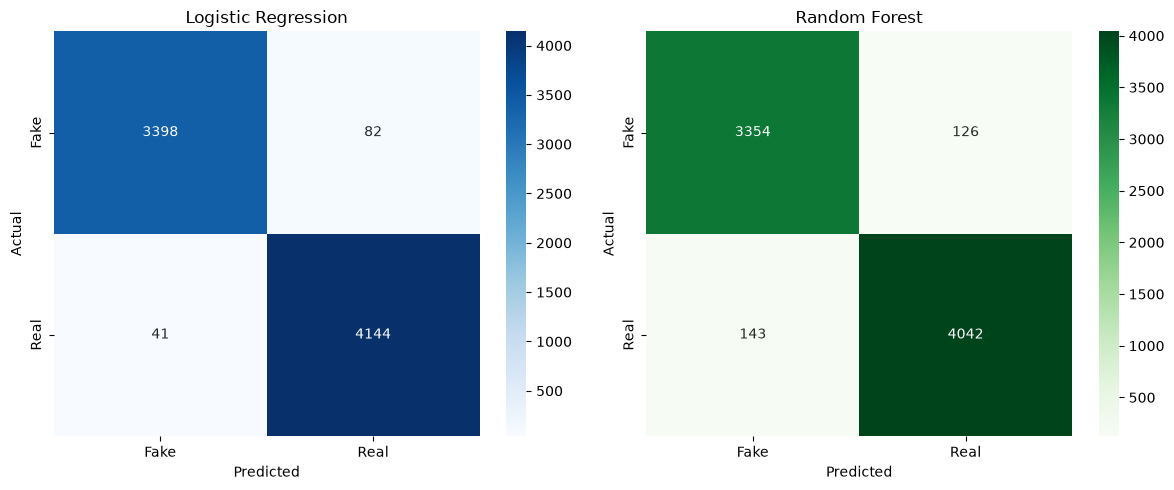

In [32]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Logistic Regression ---
cm_lr = confusion_matrix(y_test, lr_pred_test)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# --- Plot 2: Random Forest ---
# This part was missing before!
cm_rf = confusion_matrix(y_test, rf_pred_test)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [34]:
import joblib

# Save Logistic Regression
joblib.dump(lr_model, "../models/logistic_regression.pkl")

# Save Random Forest
joblib.dump(rf_model, "../models/random_forest.pkl")
print("✅ Both models saved to ../models/")

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
print("✅ TF-IDF vectorizer saved!")


✅ Both models saved to ../models/
✅ TF-IDF vectorizer saved!
